## Model: Triển khai so sánh Mô hình Naive Forecast với mô hình ARIMA/SARIMA


In [1]:
# import package
import pandas as pd 
import numpy as np
import sktime ## sktime 0.40.1

# Statistical Models
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime
from pandas import Series
from sklearn.metrics import mean_absolute_percentage_error ##sklearn<1.6.0 = 1.5.2

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

In [2]:
data = pd.read_csv('D:\\data\\ferrari\\Ferrari History Stock Data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2598 non-null   object 
 1   Close   2598 non-null   float64
 2   High    2598 non-null   float64
 3   Low     2598 non-null   float64
 4   Open    2598 non-null   float64
 5   Volume  2598 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 121.9+ KB


In [3]:
dt = data.copy()
dt['Date'] = pd.to_datetime(dt['Date'])

#### Native Forecast

In [4]:
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.utils.plotting import plot_series
print(dt.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [5]:
# Forecasting Horizon (fh): 12 kỳ kế tiếp (tương đối)
fh = np.arange(1, 13)

Đang dùng NaiveForecaster(strategy="last")


<Figure size 1200x600 with 0 Axes>

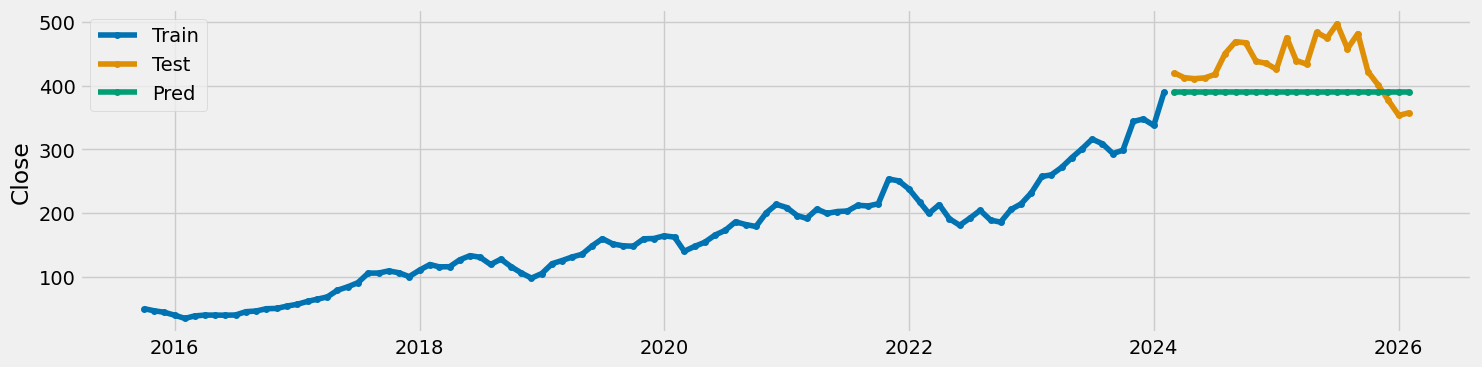

In [6]:

dt.set_index('Date', drop=False , inplace=True)
dt_monthly = dt.resample('MS').mean()

y_train, y_test = temporal_train_test_split(dt_monthly['Close'].dropna(), test_size=24)

# Lưu ý NaiveForecaster có 3 chiến lược: 'last', 'mean', 'drift'
# Dùng NaiveForecaster thuần (univariate only)
forecaster = NaiveForecaster(strategy="last")
print('Đang dùng NaiveForecaster(strategy="last")')

# Fit chỉ với chuỗi univariate
y_train = y_train.squeeze().dropna()  # đảm bảo là Series nếu là DataFrame 1 cột
forecaster.fit(y_train)

# Dự đoán
y_pred = forecaster.predict(fh)

# Vẽ biểu đồ train/test/pred
plt.figure(figsize= (12, 6))
plot_series(y_train, y_test, y_pred, labels=["Train", "Test", "Pred"])
plt.show()

#### ARIMA

In [4]:
# Set Date as index trước khi resample
Quarterly_avg = dt.set_index('Date')['Close'].resample('QE').mean()

Quarterly_avg.tail()

Date
2025-03-31    446.102193
2025-06-30    463.854560
2025-09-30    479.128438
2025-12-31    400.149062
2026-03-31    354.909412
Freq: QE-DEC, Name: Close, dtype: float64

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series, autolag= 'AIC')
    return result[1] <= 0.05

# Kiểm tra tính dừng
is_stationary = adf_test(Quarterly_avg)

# nếu ko dừng tiến hành sai phân
if not is_stationary:
    diff = Quarterly_avg.diff().dropna()
    is_diff_stationary = adf_test(diff)
else:
    is_diff_stationary = False

In [6]:
# Auto ARIMA - Tìm tham số tối ưu tự động
from pmdarima import auto_arima

# Chạy auto_arima để tìm (p, d, q) tối ưu
auto_model = auto_arima(Quarterly_avg,
                        seasonal=False,      # Không có thành phần mùa vụ
                        stepwise=True,       # Sử dụng stepwise để tìm nhanh hơn
                        trace=True,          # Hiển thị quá trình tìm kiếm
                        error_action='ignore',
                        suppress_warnings=True,
                        max_p=5,
                        max_d=2,
                        max_q=5)

print("\n=== AUTO ARIMA RESULTS ===")
print(f"Best ARIMA order (auto): {auto_model.order}")
print(f"AIC (auto): {auto_model.aic}")
print("\nModel Summary:")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=373.382, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=376.600, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=369.888, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=368.624, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=378.868, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=370.508, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=370.467, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=371.606, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=368.953, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.430 seconds

=== AUTO ARIMA RESULTS ===
Best ARIMA order (auto): (0, 1, 1)
AIC (auto): <bound method ARIMA.aic of ARIMA(order=(0, 1, 1), scoring_args={}, suppress_warnings=True)>

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   

In [7]:
# Lưu tham số auto_arima để so sánh
auto_best_order = auto_model.order
auto_best_aic = auto_model.aic

print(f"\nAuto ARIMA best order: {auto_best_order}, AIC: {auto_best_aic}")



Auto ARIMA best order: (0, 1, 1), AIC: <bound method ARIMA.aic of ARIMA(order=(0, 1, 1), scoring_args={}, suppress_warnings=True)>


In [8]:
p_values = range(0, 5)  # p (autoregressive order): Số lag của phần tự hồi quy. Ví dụ p=1 nghĩa là giá trị hiện tại phụ thuộc vào 1 giá trị trước đó.
d_values = range(0, 2)  # d thường 0 hoặc 1 cho ARIMA
q_values = range(0, 5)  # q (moving average order): Số lag của phần trung bình trượt. Ví dụ q=2 nghĩa là lỗi dự báo phụ thuộc vào 2 lỗi trước đó.
best_aic = float('inf')
best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            try:
                model = ARIMA(Quarterly_avg, order = order)
                model_fit = model.fit()
                aic = model_fit.aic
                if aic < best_aic:
                    best_aic = aic
                    best_order = order
            except:
                continue

-> Đưa dữ liệu vào model

In [9]:
model = ARIMA(Quarterly_avg, order = best_order)
model_fit = model.fit()

print(f"Sử dụng tham số: {best_order}")
model_fit

Sử dụng tham số: (3, 1, 2)


Đưa ra dư đoán cho 4 Quý tiếp theo (1 năm sau) - Time Forecasting

In [10]:
forecast = model_fit.forecast(steps = 4)

forecast

2026-06-30    342.215706
2026-09-30    339.761428
2026-12-31    323.932631
2027-03-31    299.434316
Freq: QE-DEC, Name: predicted_mean, dtype: float64

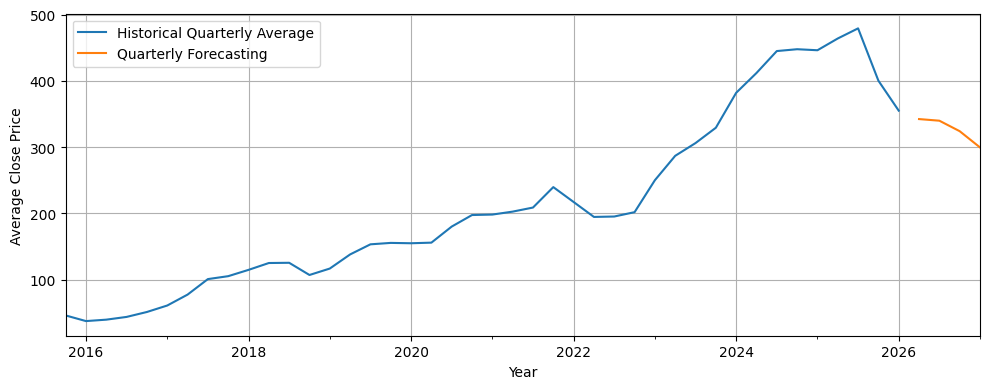

In [11]:
plt.figure(figsize = (10, 4))
Quarterly_avg.plot(label = 'Historical Quarterly Average', legend= True)
forecast.plot(label = 'Quarterly Forecasting', legend = True)

plt.title('')
plt.xlabel('Year')
plt.ylabel('Average Close Price')

plt.grid()
plt.tight_layout()
plt.show()

In [12]:
Quarterly_avg

Date
2015-12-31     45.839737
2016-03-31     37.316220
2016-06-30     39.474350
2016-09-30     43.608081
2016-12-31     51.062589
2017-03-31     60.819704
2017-06-30     77.281349
2017-09-30    100.705101
2017-12-31    105.106131
2018-03-31    114.612563
2018-06-30    124.964463
2018-09-30    125.305804
2018-12-31    106.902695
2019-03-31    116.606158
2019-06-30    137.923874
2019-09-30    153.177283
2019-12-31    155.319277
2020-03-31    154.789386
2020-06-30    155.704225
2020-09-30    179.960869
2020-12-31    197.381469
2021-03-31    198.081473
2021-06-30    202.540403
2021-09-30    208.685620
2021-12-31    239.524950
2022-03-31    217.049452
2022-06-30    194.521287
2022-09-30    195.139288
2022-12-31    201.711497
2023-03-31    249.964795
2023-06-30    286.771223
2023-09-30    306.007218
2023-12-31    329.140902
2024-03-31    381.880816
2024-06-30    411.792162
2024-09-30    444.877701
2024-12-31    447.649358
2025-03-31    446.102193
2025-06-30    463.854560
2025-09-30    479.12

Do ARIMA thông thường (không có seasonality) nên có thể dự đoán ở mức Quý (do dữ liệu quý thg ít seasonality đủ mạnh để ảnh hưởng lớn)

-> Dẫn đến mô hình không capture đc patten này: mô hình ko hội tụ, dữ liệu giống nhau, AIC ko tối ưu (Quý: 40-50 đ dữ liệu)

--> Sau đây ta dùng SARIMA (Seasonality ARIMA), thuật toán mạnh mẽ trong việc dự đoán dữ liệu dày hơn (120-130 đ dữ liệu)